In [17]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix

import sys
sys.path.append('./ml_utils')
from mesh_utils_optimized import find_best_model
from sklearn.metrics import accuracy_score


In [18]:
print("Loading dataset...")
df = pd.read_csv("movie_metadata.csv")
print(f"Dataset Shape: {df.shape}")
df.head() # Displays the first 5 rows to ensure it loaded correctly

Loading dataset...
Dataset Shape: (5043, 28)


,color,director_name,num_critic_for_reviews,duration,director_facebook_likes,actor_3_facebook_likes,actor_2_name,actor_1_facebook_likes,gross,genres,...,num_user_for_reviews,language,country,content_rating,budget,title_year,actor_2_facebook_likes,imdb_score,aspect_ratio,movie_facebook_likes
0,Color,James Cameron,723.0,178.0,0.0,855.0,Joel David Moore,1000.0,760505847.0,Action|Adventure|Fantasy|Sci-Fi,...,3054.0,English,USA,PG-13,237000000.0,2009.0,936.0,7.9,1.78,33000
1,Color,Gore Verbinski,302.0,169.0,563.0,1000.0,Orlando Bloom,40000.0,309404152.0,Action|Adventure|Fantasy,...,1238.0,English,USA,PG-13,300000000.0,2007.0,5000.0,7.1,2.35,0
2,Color,Sam Mendes,602.0,148.0,0.0,161.0,Rory Kinnear,11000.0,200074175.0,Action|Adventure|Thriller,...,994.0,English,UK,PG-13,245000000.0,2015.0,393.0,6.8,2.35,85000
3,Color,Christopher Nolan,813.0,164.0,22000.0,23000.0,Christian Bale,27000.0,448130642.0,Action|Thriller,...,2701.0,English,USA,PG-13,250000000.0,2012.0,23000.0,8.5,2.35,164000
4,NaN,Doug Walker,NaN,NaN,131.0,NaN,Rob Walker,131.0,NaN,Documentary,...,NaN,NaN,NaN,NaN,NaN,NaN,12.0,7.1,NaN,0


In [19]:
print("Cleaning data and handling missing values...")

# Drop rows where the target variable is missing
df = df.dropna(subset=['imdb_score'])

# Drop columns that offer no predictive value
if 'movie_imdb_link' in df.columns:
    df = df.drop(columns=['movie_imdb_link'])

# Fill missing numericals with median, categoricals with mode/Unknown
num_cols = df.select_dtypes(include=[np.number]).columns
cat_cols = df.select_dtypes(include=['object']).columns

for col in num_cols:
    df[col] = df[col].fillna(df[col].median())
for col in cat_cols:
    if col in ['director_name', 'actor_1_name', 'actor_2_name', 'actor_3_name', 'plot_keywords']:
        df[col] = df[col].fillna('Unknown')
    else:
        df[col] = df[col].fillna(df[col].mode()[0])

print("Creating target variable 'Classify'...")
bins = [0, 3, 6, 10]
labels = ['Flop', 'Average', 'Hit']
df['Classify'] = pd.cut(df['imdb_score'], bins=bins, labels=labels, include_lowest=True)

# CRITICAL: Drop the imdb_score so the model doesn't cheat!
df = df.drop(columns=['imdb_score'])
print("Preprocessing complete. IMDB score removed.")

Cleaning data and handling missing values...
Creating target variable 'Classify'...
Preprocessing complete. IMDB score removed.


In [20]:
print("Addressing multicollinearity...")
# Find and drop highly correlated numerical features
num_features = df.select_dtypes(include=[np.number])
corr_matrix = num_features.corr().abs()
upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
to_drop = [column for column in upper.columns if any(upper[column] > 0.80)]
print(f"Dropping highly correlated columns: {to_drop}")
df = df.drop(columns=to_drop)

# Prepare X (features) and y (target)
X = df.drop(columns=['Classify'])
y = df['Classify']

# Label Encode categorical features
print("Encoding categorical variables...")
for col in X.select_dtypes(include=['object', 'category']).columns:
    le = LabelEncoder()
    X[col] = le.fit_transform(X[col].astype(str))

# Scale features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Split into Train and Test sets
print("Splitting data into training and testing sets...")
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42, stratify=y)
print("Data split successfully.")

Addressing multicollinearity...
Dropping highly correlated columns: ['cast_total_facebook_likes']
Encoding categorical variables...
Splitting data into training and testing sets...
Data split successfully.


In [21]:
print("--- Model 1: Logistic Regression (Baseline) ---")
log_model = LogisticRegression(max_iter=1000, random_state=42, class_weight='balanced')
log_model.fit(X_train, y_train)
log_preds = log_model.predict(X_test)
print(classification_report(y_test, log_preds))

print("\n--- Model 2: Random Forest Classifier ---")
rf_model = RandomForestClassifier(n_estimators=100, max_depth=15, random_state=42, class_weight='balanced')
rf_model.fit(X_train, y_train)
rf_preds = rf_model.predict(X_test)
print(classification_report(y_test, rf_preds))

--- Model 1: Logistic Regression (Baseline) ---
              precision    recall  f1-score   support

     Average       0.47      0.55      0.51       308
        Flop       0.04      0.78      0.08         9
         Hit       0.88      0.61      0.72       692

    accuracy                           0.59      1009
   macro avg       0.46      0.65      0.43      1009
weighted avg       0.75      0.59      0.65      1009


--- Model 2: Random Forest Classifier ---
              precision    recall  f1-score   support

     Average       0.72      0.60      0.66       308
        Flop       0.00      0.00      0.00         9
         Hit       0.83      0.90      0.87       692

    accuracy                           0.80      1009
   macro avg       0.52      0.50      0.51      1009
weighted avg       0.79      0.80      0.80      1009



C:\Users\soume\AppData\Roaming\Python\Python312\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\soume\AppData\Roaming\Python\Python312\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\soume\AppData\Roaming\Python\Python312\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capital

Generating Confusion Matrix Visualizations...


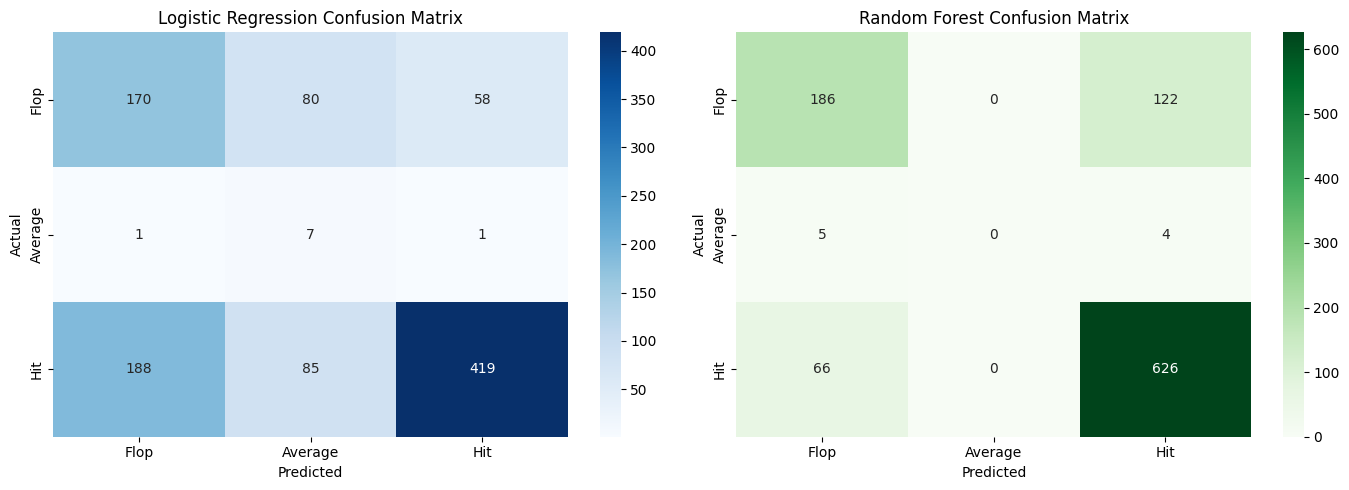

In [22]:
print("Generating Confusion Matrix Visualizations...")
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot Logistic Regression Confusion Matrix
sns.heatmap(confusion_matrix(y_test, log_preds), annot=True, fmt='d', cmap='Blues', ax=axes[0], 
            xticklabels=labels, yticklabels=labels)
axes[0].set_title('Logistic Regression Confusion Matrix')
axes[0].set_ylabel('Actual')
axes[0].set_xlabel('Predicted')

# Plot Random Forest Confusion Matrix
sns.heatmap(confusion_matrix(y_test, rf_preds), annot=True, fmt='d', cmap='Greens', ax=axes[1], 
            xticklabels=labels, yticklabels=labels)
axes[1].set_title('Random Forest Confusion Matrix')
axes[1].set_ylabel('Actual')
axes[1].set_xlabel('Predicted')

plt.tight_layout()
plt.show()

In [23]:
print("\n--- Model 3: Finding Best Model using mesh_utils_optimized ---")
import sys
sys.path.append('./ml_utils')
import mesh_utils_optimized
from sklearn.metrics import accuracy_score
from sklearn.preprocessing import LabelEncoder

# Encode y for XGBoost which requires integer labels [0, 1, 2] instead of strings
le = LabelEncoder()
y_encoded = le.fit_transform(y)

# Fix the LogisticRegression instance in mesh_utils_optimized to support multiclass
# 'liblinear' does not support multiclass natively without OneVsRest. 'lbfgs' does.
lr_model = mesh_utils_optimized.classification_models["Logistic Regression"][0]
lr_model.set_params(solver='lbfgs', max_iter=2000)

# find_best_model does its own train_test_split internally with the same seed
best_model_results = mesh_utils_optimized.find_best_model(X_scaled, y_encoded, problem_type='classification', metric='accuracy', n_iter=5)

print(f"\n✓ Best Model found: {best_model_results['best_model_name']}")
print(f"✓ CV Accuracy: {best_model_results['CV_score']:.4f}")
print(f"✓ Test Accuracy: {best_model_results['Test_score']:.4f}")
print(f"✓ Best Parameters: {best_model_results['best_params']}")

# Compare Random Forest test accuracy to the best model test accuracy
rf_test_acc = accuracy_score(y_test, rf_preds)
print(f"\n--- Comparison ---")
print(f"Random Forest Test Accuracy: {rf_test_acc:.4f}")
print(f"Best Model ({best_model_results['best_model_name']}) Test Accuracy: {best_model_results['Test_score']:.4f}")
if best_model_results['Test_score'] > rf_test_acc:
    print("\nThe model found by mesh_utils is more accurate than the baseline Random Forest!")
else:
    print("\nThe baseline Random Forest is equal to or more accurate than the model found by mesh_utils.")



--- Model 3: Finding Best Model using mesh_utils_optimized ---
Training models for classification using accuracy (RandomizedSearchCV)...

✓ Best Model found: xgboost
✓ CV Accuracy: 0.8024
✓ Test Accuracy: 0.8176
✓ Best Parameters: {'subsample': 0.8, 'n_estimators': 200, 'max_depth': 7, 'learning_rate': 0.1}

--- Comparison ---
Random Forest Test Accuracy: 0.8048
Best Model (xgboost) Test Accuracy: 0.8176

The model found by mesh_utils is more accurate than the baseline Random Forest!


In [24]:
import joblib
import os

try:
    # 1. Create the models directory within the project if it doesn't exist
    models_dir = './models'
    os.makedirs(models_dir, exist_ok=True)

    # 2. Export the trained best model to that folder
    # We will save the best model found by mesh_utils as well as the random forest model
    model_path = os.path.join(models_dir, 'best_movie_model.pkl')
    
    # Check if best_model_results exists from the previous cell
    if 'best_model_results' in locals() and best_model_results.get('trained_model') is not None:
        joblib.dump(best_model_results['trained_model'], model_path)
        print(f"Success! Best model ({best_model_results['best_model_name']}) has been saved to: {model_path}")
    
    elif 'rf_model' in locals():
        # Fallback to Random Forest
        rf_path = os.path.join(models_dir, 'rf_movie_model.pkl')
        joblib.dump(rf_model, rf_path)
        print(f"Success! Random Forest model has been saved to: {rf_path}")
    
    else:
        print("No trained models found to export in the current session.")
        
except Exception as e:
    print(f"An error occurred while exporting the model: {e}")


Success! Best model (xgboost) has been saved to: ./models\best_movie_model.pkl
